# Learning Cats

As quantum hardware scales in complexity and circuit depth, efficient and robust calibration becomes increasingly critical. Traditional model-based calibration methods struggle to track the non-stationary and interdependent nature of optimal control parameters. They also suffer from the simulation-to-reality gap, where strategies that perform well in simulation degrade on real hardware due to unmodeled dynamics, noise, and drift.

Reinforcement learning (RL) has recently emerged as a promising approach for adaptive, model-free control of quantum systems [1]. In particular, RL has been shown to extend the lifetime of error-corrected logical qubits beyond what is achievable with conventional calibration techniques, while maintaining performance under changing hardware conditions [2].

Dissipative cat qubits, while offering improved hardware efficiency and reduced control overhead compared to transmon-based approaches, face similar challenges in calibration and robustness to drift. In this challenge, you will explore model-free, measurement-based control strategies (including and beyond RL) for the stabilization and control of dissipative cat qubits.


---
1. Real-time quantum error correction beyond break-even, Volodymyr Sivak et al. (2023). [https://arxiv.org/abs/2211.09116](https://arxiv.org/abs/2211.09116)
2. Reinforcement Learning Control of Quantum Error Correction, Volodymyr Sivak et al. (2025). [https://arxiv.org/abs/2511.08493](https://arxiv.org/abs/2511.08493)

# Imports

In [2]:
# # use a python 3.11 environment, and install dynamiqs >= 0.3.0

# uncomment and run the line below once to install the required dependencies. You can also install these packages in your terminal using pip.
# !pip install "dynamiqs>=0.3.0" cmaes scipy

  Using cached dynamiqs-0.3.4-py3-none-any.whl.metadata (14 kB)
  Using cached jax-0.6.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxtyping-0.3.9-py3-none-any.whl.metadata (7.4 kB)
  Using cached diffrax-0.7.2-py3-none-any.whl.metadata (18 kB)
  Using cached equinox-0.13.6-py3-none-any.whl.metadata (19 kB)
  Using cached optimistix-0.1.0-py3-none-any.whl.metadata (18 kB)
  Using cached cmap-0.7.2-py3-none-any.whl.metadata (8.2 kB)
  Using cached jaxlib-0.6.2-cp313-cp313-win_amd64.whl.metadata (1.4 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached lineax-0.1.0-py3-none-any.whl.metadata (18 kB)
  Using cached wadler_lindig-0.1.7-py3-none-any.whl.metadata (17 kB)
Using cached dynamiqs-0.3.4-py3-none-any.whl (159 kB)
Using cached jax-0.6.2-py3-none-any.whl (2.7 MB)
Using cached jaxlib-0.6.2-cp313-cp313-win_amd64.whl (57.9 MB)
Using cached diffrax-0.7.2-py3-none-any.whl (19

In [3]:
import dynamiqs as dq
import jax.numpy as jnp
from matplotlib import pyplot as plt

from jax import vmap, jit
from cmaes import SepCMA

from scipy.optimize import curve_fit
from scipy.optimize import least_squares

# dq.set_progress_meter(False)

# Simple Pi Pulse

Let us begin with a simple example of a tuning the control parameters of an ideal qubit. To do so, we will utilize Alice and Bob's open-source quantum simulation package, [`dynamiqs`](https://www.dynamiqs.org/).  

## Amplitude Frequency Rabi Chevron

First, we sweep the amplitude and frequency of a transverse drive (e.g., along $\sigma_x$) applied to an ideal qubit in order to implement a $\pi$-pulse.

In [5]:
fq = 5 # [GHz]
H0 = 2 * jnp.pi * fq * dq.sigmaz() / 2

g_d = 2 * jnp.pi * 0.01 # [GHz]

omega_01 = 2 * jnp.pi * fq
omegas = omega_01 + 2 * jnp.pi * jnp.linspace(-0.02, 0.02, 41) 

amp_factors = jnp.linspace(0, 4.0, 51).reshape(-1, 1) # [amp_factor, 1]

f = lambda t: amp_factors * g_d * jnp.cos(omegas * t)
Hx = dq.modulated(f, dq.sigmax())
Ht = H0 + Hx

g_ket = dq.basis(2, 0)
e_ket = dq.basis(2, 1)

ts = jnp.linspace(0, 50, 2)


results = dq.sesolve(
    Ht,
    g_ket,
    ts,
    
)

|███████████████████████████████████████████████████████████████████████████| 100.0% ◆ elapsed 6.63s ◆ remaining 0.00ms


If we use $\langle \sigma_z \rangle$ as the color scale, we can directly identify when a complete $\pi$-pulse has occurred, namely when $\langle \sigma_z \rangle = -1$. To improve the visual contrast of the resulting 2D plot, it is useful to instead plot $\log_{10}\!\big(1 + \langle \sigma_z \rangle\big)$, which enhances variations near $\langle \sigma_z \rangle = -1$.

Text(0.5, 1.0, '$⟨σ_z⟩$')

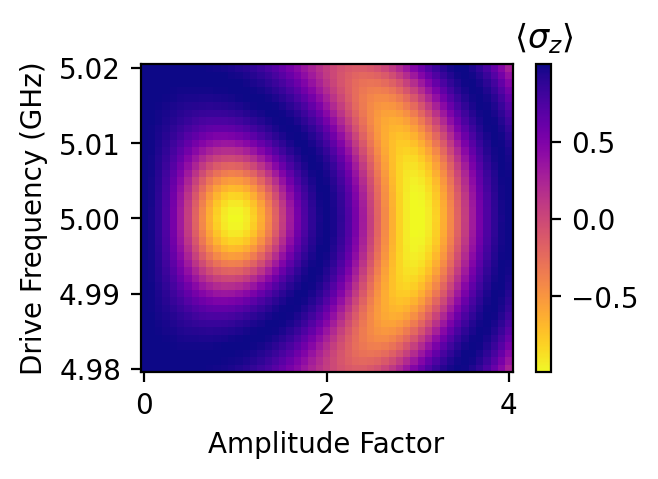

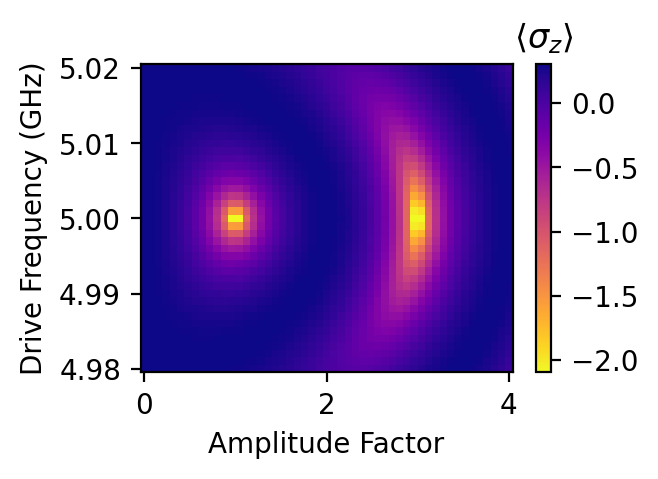

In [6]:
szt = dq.expect(dq.sigmaz(), results.states)
szt = szt[:,:,-1].reshape(szt.shape[0], szt.shape[1])

fig, ax = plt.subplots(1,1, figsize=(3,2), dpi=200)

im = ax.pcolormesh(amp_factors.flatten(), omegas / (2 * jnp.pi), szt.real.T, cmap="plasma_r")

ax.set_xlabel("Amplitude Factor")
ax.set_ylabel("Drive Frequency (GHz)")
cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_title("$⟨σ_z⟩$")


# Plotting log infidelity for better contrast

fig, ax = plt.subplots(1,1, figsize=(3,2), dpi=200)

im = ax.pcolormesh(amp_factors.flatten(), omegas / (2 * jnp.pi), jnp.log10(1+szt.real.T), cmap="plasma_r")

ax.set_xlabel("Amplitude Factor")
ax.set_ylabel("Drive Frequency (GHz)")
cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_title("$⟨σ_z⟩$")

## Loss Function + Optimization

The following section demonstrates how online (i.e., measurement-based) optimization can be used to achieve optimal control of quantum systems. In this example, we define a loss function whose minimization yields a high-fidelity $\pi$-pulse gate. The corresponding control parameters are the amplitude and frequency of the $\pi$-pulse drive.

In [4]:
@jit 
def pi_pulse_loss_func(x):
    amp_factor_delta = x[0]
    freq_delta_MHz = x[1]

    fq = 5 # [GHz]
    H0 = 2 * jnp.pi * fq * dq.sigmaz() / 2

    g_d = 2 * jnp.pi * 0.01 # [GHz]

    omega = 2 * jnp.pi * (fq + freq_delta_MHz * 1e-3)
    
    f = lambda t: (1 + amp_factor_delta) * g_d * jnp.cos(omega * t)
    Hx = dq.modulated(f, dq.sigmax())
    Ht = H0 + Hx

    g_ket = dq.basis(2, 0)
    e_ket = dq.basis(2, 1)

    ts = jnp.linspace(0, 50, 2)


    results = dq.sesolve(
        Ht,
        g_ket,
        ts,   
        options=dq.Options(
            progress_meter=False
        )
    )

    szt = dq.expect(dq.sigmaz(), results.states[-1])
    return jnp.log10(1+szt.real)

# NOTE: By applying \texttt{jit} and \texttt{vmap} to the loss function, we can evaluate a JIT-compiled, batched version of the loss efficiently.
batched_pi_pulse_loss_func = jit(vmap(pi_pulse_loss_func))

In [5]:
# Example evaluation / heating 

xs = jnp.array([
    [0.0, 0.0],
    [0.5, 0.0]
])

print(pi_pulse_loss_func(xs[0]))
print(batched_pi_pulse_loss_func(xs))

-3.8514397
[-3.8514397e+00  7.6621782e-06]


To illustrate that an online optimizer need not be reinforcement learning-based, we use the CMA-ES optimizer here, which has demonstrated strong performance in other quantum control applications [1].

---
1. Benchmarking Optimization Algorithms for Automated Calibration of Quantum Devices, Kevin Pack et al (2025). https://arxiv.org/pdf/2509.08555v2 

In [6]:
# NOTE: hyperparameters for the optimization

BATCH_SIZE = 12
N_EPOCHS = 80

# ----------------------------------------
# CMA-ES setup
# ----------------------------------------

mean0 = jnp.array([0.5, 2])     # start near optimum
sigma0 = 0.2                     # exploration scale

optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    bounds=jnp.array([
        [-1.0, 1.0],    # amp_factor bounds
        [-5.0, 5.0],   # freq_delta_MHz bounds
    ]),
    population_size=BATCH_SIZE,
    seed=0,
)

# ----------------------------------------
# Logging
# ----------------------------------------
mean_history = []
reward_history = []
reward_std_history = []

# ----------------------------------------
# Training loop
# ----------------------------------------
for epoch in range(N_EPOCHS):
    solutions = []

    # Sample population
    xs = []
    for _ in range(optimizer.population_size):
        xs.append(optimizer.ask())

    xs = jnp.array(xs)
    rewards = batched_pi_pulse_loss_func(xs)

    # Format solutions
    solutions = []
    for j in range(len(xs)):
        solutions.append((xs[j], rewards[j]))

    optimizer.tell(solutions)

    # Log
    mean_history.append(optimizer.mean.copy())
    reward_history.append(jnp.mean(rewards))
    reward_std_history.append(jnp.std(rewards))

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | mean={optimizer.mean} | avg reward={jnp.mean(rewards):.4f}")



Epoch   0 | mean=[0.32209173 2.1048439 ] | avg reward=0.0706
Epoch  10 | mean=[-0.01844766  1.088579  ] | avg reward=-1.1771
Epoch  20 | mean=[-0.0005504  -0.00504249] | avg reward=-3.7201
Epoch  30 | mean=[-0.00042585 -0.0016721 ] | avg reward=-3.8271
Epoch  40 | mean=[-0.00038997  0.00044618] | avg reward=-3.7960
Epoch  50 | mean=[-0.00025518 -0.00140355] | avg reward=-3.8229
Epoch  60 | mean=[-6.381130e-05 -4.089323e-04] | avg reward=-3.8490
Epoch  70 | mean=[-0.00030375  0.00043261] | avg reward=-3.8213


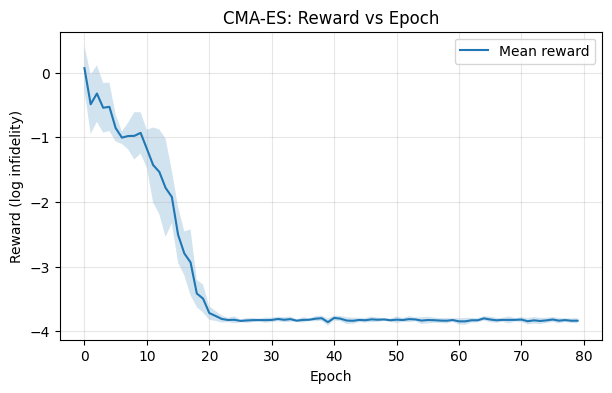

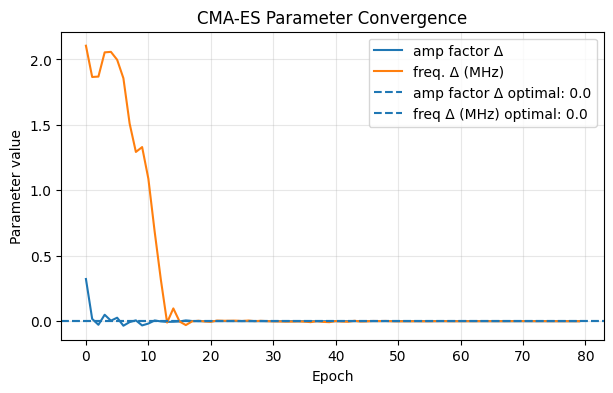

In [7]:

mean_history = jnp.array(mean_history)
reward_history = jnp.array(reward_history)
reward_std_history = jnp.array(reward_std_history)


# ----------------------------------------
# Plot 1: Reward vs epoch
# ----------------------------------------
epochs = jnp.arange(N_EPOCHS)

plt.figure(figsize=(7, 4))
plt.plot(epochs, reward_history, label="Mean reward")
plt.fill_between(
    epochs,
    reward_history - reward_std_history,
    reward_history + reward_std_history,
    alpha=0.2,
)
plt.xlabel("Epoch")
plt.ylabel("Reward (log infidelity)")
plt.title("CMA-ES: Reward vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ----------------------------------------
# Plot 2: Parameters vs epoch
# ----------------------------------------
plt.figure(figsize=(7, 4))

plt.plot(epochs, mean_history[:, 0], label="amp factor Δ")
plt.plot(epochs, mean_history[:, 1], label="freq. Δ (MHz)")

# true optimum
plt.axhline(0.0, linestyle="--", label="amp factor Δ optimal: 0.0")
plt.axhline(0.0, linestyle="--", label="freq Δ (MHz) optimal: 0.0")

plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("CMA-ES Parameter Convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Loss Function + Optimization / Under Drift

A key feature of real quantum hardware is the presence of drift in device conditions and calibration settings, which is often difficult to model accurately. As a result, the optimal control parameters are generally non-stationary over time, and this behavior must be taken into account when benchmarking online controllers. In practice, an effective online control strategy should be able to track and compensate for such drift.

To illustrate this, we now introduce drift into the loss function and examine whether the optimizer can adapt quickly enough to keep pace.

In [8]:
@jit
def pi_pulse_loss_func_under_drift(p):
    num_knobs = 2
    

    amp_factor_delta = p[0]
    freq_delta_MHz = p[1]

    amp_factor_delta_drift = p[num_knobs + 0]
    freq_delta_MHz_drift = p[num_knobs + 1]

    fq = 5 # [GHz]
    H0 = 2 * jnp.pi * fq * dq.sigmaz() / 2

    g_d = 2 * jnp.pi * 0.01 # [GHz]

    omega = 2 * jnp.pi * (fq + freq_delta_MHz * 1e-3 - freq_delta_MHz_drift * 1e-3)
    
    f = lambda t: (1 + amp_factor_delta - amp_factor_delta_drift) * g_d * jnp.cos(omega * t)
    Hx = dq.modulated(f, dq.sigmax())
    Ht = H0 + Hx

    g_ket = dq.basis(2, 0)
    e_ket = dq.basis(2, 1)

    ts = jnp.linspace(0, 50, 2)


    results = dq.sesolve(
        Ht,
        g_ket,
        ts,   
        options=dq.Options(
            progress_meter=False
        )
    )

    szt = dq.expect(dq.sigmaz(), results.states[-1])
    return jnp.log10(1+szt.real)

batched_pi_pulse_loss_func_under_drift = jit(vmap(pi_pulse_loss_func_under_drift))

In [9]:
ps = jnp.array([
    [0.0, 0.0, 0.0, 0.0],
    [0.5, 2.0, 0.5, 2.0]
])

print(pi_pulse_loss_func_under_drift(ps[0]))
print(batched_pi_pulse_loss_func_under_drift(ps))

-3.8514397
[-3.8514397 -3.8514397]


In [10]:
BATCH_SIZE = 12
N_EPOCHS = 200
N_KNOBS = 2


# SYNTHETIC DRIFT
# ----------------------------------------
amp_factor_delta_drift_func = lambda ep: 0.8 * jnp.sin(2 * jnp.pi * 0.01 * ep)
# ----------------------------------------


# ----------------------------------------
# CMA-ES setup
# ----------------------------------------

mean0 = jnp.array([0.5, 2])     # start near optimum
sigma0 = 0.2                     # exploration scale

optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    bounds=jnp.array([
        [-1.0, 1.0],    # amp_factor bounds
        [-5.0, 5.0],   # freq_delta_MHz bounds
    ]),
    population_size=BATCH_SIZE,
    seed=0,
)

# ----------------------------------------
# Logging
# ----------------------------------------
mean_history = []
std_history = []
reward_history = []
reward_std_history = []
drift_history = []

# ----------------------------------------
# Training loop
# ----------------------------------------
for epoch in range(N_EPOCHS):
    solutions = []

    drift_history.append([amp_factor_delta_drift_func(epoch), 0.0])

    # Sample population
    xs = []
    for _ in range(optimizer.population_size):
        xs.append(jnp.array(optimizer.ask().tolist() + drift_history[-1]))

    xs = jnp.array(xs)
    rewards = batched_pi_pulse_loss_func_under_drift(xs)

    # Format solutions
    solutions = []
    for j in range(len(xs)):
        solutions.append((xs[j][:N_KNOBS], rewards[j]))

    optimizer.tell(solutions)

    # Log
    mean_history.append(jnp.mean(xs[:,:N_KNOBS], axis=0))
    std_history.append(jnp.std(xs[:,:N_KNOBS], axis=0))
    reward_history.append(jnp.mean(rewards))
    reward_std_history.append(jnp.std(rewards))

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | param mean={mean_history[-1]} | param std {std_history[-1]} | avg reward={jnp.mean(rewards):.4f}")



Epoch   0 | param mean=[0.6154126 2.0447474] | param std [0.22261414 0.17998385] | avg reward=0.0706
Epoch  10 | param mean=[0.35302815 1.3657182 ] | param std [0.07453622 0.17984335] | avg reward=-0.9844
Epoch  20 | param mean=[ 0.7459178  -0.01101881] | param std [0.05264929 0.21018592] | avg reward=-2.0124
Epoch  30 | param mean=[ 0.7805877  -0.08837091] | param std [0.01687402 0.09945064] | avg reward=-2.7147
Epoch  40 | param mean=[0.5250188  0.04280893] | param std [0.05270714 0.1811487 ] | avg reward=-2.0127
Epoch  50 | param mean=[ 0.1406047  -0.11384325] | param std [0.12642689 0.25353774] | avg reward=-1.0661
Epoch  60 | param mean=[-0.41919136 -0.11982177] | param std [0.09521105 0.22751375] | avg reward=-1.5271
Epoch  70 | param mean=[-0.7222848  0.0689306] | param std [0.03341585 0.15362877] | avg reward=-2.1389
Epoch  80 | param mean=[-0.77606285  0.04915612] | param std [0.00859669 0.07235252] | avg reward=-2.8987
Epoch  90 | param mean=[-0.57848006 -0.05569011] | param 

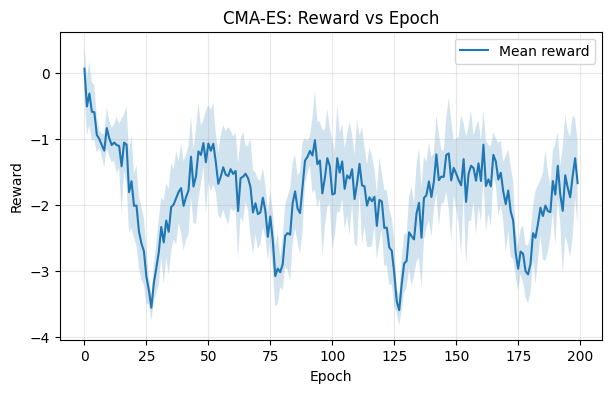

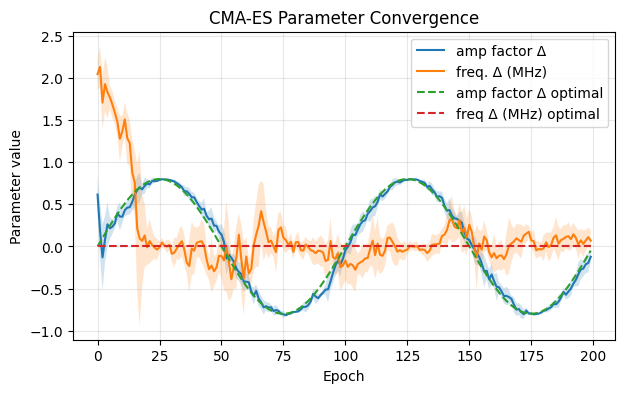

In [11]:

mean_history = jnp.array(mean_history)
std_history = jnp.array(std_history)
reward_history = jnp.array(reward_history)
reward_std_history = jnp.array(reward_std_history)
drift_history = jnp.array(drift_history)


# ----------------------------------------
# Plot 1: Reward vs epoch
# ----------------------------------------
epochs = jnp.arange(N_EPOCHS)

plt.figure(figsize=(7, 4))
plt.plot(epochs, reward_history, label="Mean reward")
plt.fill_between(
    epochs,
    reward_history - reward_std_history,
    reward_history + reward_std_history,
    alpha=0.2,
)
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.title("CMA-ES: Reward vs Epoch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# ----------------------------------------
# Plot 2: Parameters vs epoch
# ----------------------------------------
plt.figure(figsize=(7, 4))

plt.plot(epochs, mean_history[:, 0], label="amp factor Δ")
plt.fill_between(
    epochs,
    mean_history[:, 0] - std_history[:, 0],
    mean_history[:, 0] + std_history[:, 0],
    alpha=0.2,
)

plt.plot(epochs, mean_history[:, 1], label="freq. Δ (MHz)")
plt.fill_between(
    epochs,
    mean_history[:, 1] - std_history[:, 1],
    mean_history[:, 1] + std_history[:, 1],
    alpha=0.2,
)

# true optimum
plt.plot(drift_history[:, 0], linestyle="--", label="amp factor Δ optimal")
plt.plot(drift_history[:, 1], linestyle="--", label="freq Δ (MHz) optimal")

plt.xlabel("Epoch")
plt.ylabel("Parameter value")
plt.title("CMA-ES Parameter Convergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Great! We can clearly see that the mean qubit $\pi$-pulse amplitude and frequency track the drift over time.

# Cat Qubit Stabilization

## Introducing the system

Please review the following tutorial for a great introduction to cat qubits:
`resources/Tutorial__Introduction_to_Cats.ipynb`

The above tutorial shows that two photon dissipation can be used to stabilize the codespace of a cat qubit. As shown below, if we start from vacuum and turn on engineered dissipation of the form $\hat{L}_2 = \sqrt{\kappa_2}\left(\hat{a}^2 - \alpha^2\right)$, we evolve into an odd cat state. 

|██████████| 100.0% ◆ elapsed 12.52ms ◆ remaining 0.00ms
100%|██████████| 50/50 [00:02<00:00, 17.93it/s]


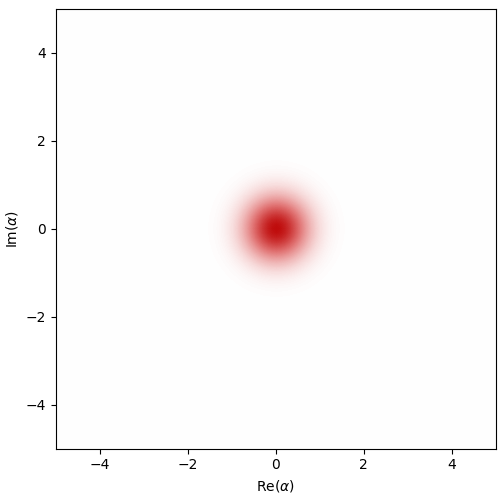

In [12]:
na = 15 # Hilbert space dimension
a = dq.destroy(na) # annihilaiton operator
psi0 = dq.fock(na, 0) # initial state
H = dq.zeros(na) # zero Hamiltonian
kappa_2 = 1 # two-photon loss rate
alpha = 2.0 # cat size
tsave = jnp.linspace(0, 3, 100)
loss_op = jnp.sqrt(kappa_2)*(a @ a - alpha**2 * dq.eye(na)) # loss operator
res = dq.mesolve(H, [loss_op], psi0, tsave)
dq.plot.wigner_gif(res.states)

In practice, the dominant loss mechanism in a resonator is single-photon loss. Cat qubits provide an encoding that protects logical quantum information against this process by exploiting a strong noise bias.

As discussed above, stabilizing a cat qubit requires engineering an additional dissipation channel. This allows us to counteract the detrimental effects of single-photon loss using two-photon processes. Intuitively, the engineered dynamics continuously steer the system back into the protected cat subspace, even in the presence of noise.

In particular, the jump operator
$\hat{L}_2 = \sqrt{\kappa_2}\left(\hat{a}^2 - \alpha^2\right)$
can be reinterpreted as arising from a combination of two-photon dissipation and a coherent two-photon drive, as shown below. This decomposition connects the abstract Lindblad description to a physically realizable implementation in circuit QED systems. 

$$H/\hbar = i\epsilon_2 (a^\dagger)^2 - i \epsilon_2^* a^2,\ L_2 = \sqrt{\kappa_2} a^2,\ L_1 = \sqrt{\kappa_a} a $$



Estimated cat size: 2.00


|██████████| 100.0% ◆ elapsed 14.71ms ◆ remaining 0.00ms
100%|██████████| 50/50 [00:02<00:00, 16.73it/s]


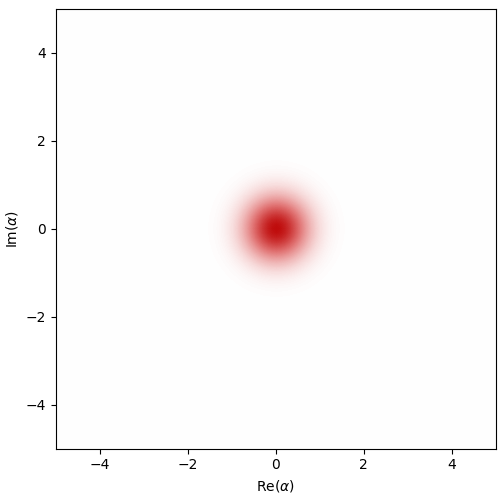

In [13]:
na = 15 # Hilbert space dimension
a = dq.destroy(na) # annihilaiton operator
psi0 = dq.fock(na, 0) # initial state

eps_2 = 2 # MHz
kappa_2 = 1 # MHz
kappa_a = 0 # turning single photon loss off for now
alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

print(f"Estimated cat size: {alpha_estimate:.2f}")

H = 1j*eps_2 * a.dag() @ a.dag() - 1j*jnp.conj(eps_2) * a @ a

loss_a2 = jnp.sqrt(kappa_2)* a @ a
loss_a = jnp.sqrt(kappa_a)* a

tsave = jnp.linspace(0, 3, 100) # us

res = dq.mesolve(H, [loss_a2, loss_a], psi0, tsave)
dq.plot.wigner_gif(res.states)

Following Ref. [1], the two-photon dissipation mechanism described above can be engineered by coupling the storage mode $a$ to a lossy auxiliary mode $b$, often referred to as the *buffer*. This is achieved via a two-to-one photon exchange interaction, described by the Hamiltonian
$$
H/\hbar = g_2^* a^2 b^\dagger + g_2 (a^\dagger)^2 b - \epsilon_d b^\dagger - \epsilon_d^* b,
$$
with corresponding dissipation channels
$$
L_b = \sqrt{\kappa_b}\, b, \quad L_a = \sqrt{\kappa_a}\, a.
$$

In the regime where the buffer decay rate is fast compared to the interaction strength, $\kappa_b \gg |g_2|$, the buffer mode can be adiabatically eliminated. In this limit, the dynamics of the storage mode reduce to an effective two-photon dissipation process, recovering the jump operator $\hat{L}_2 = \sqrt{\kappa_2}(a^2 - \alpha^2)$ introduced earlier.

---

1. One hundred second bit-flip time in a two-photon dissipative oscillator, C. Berdou et al. (2022). https://arxiv.org/pdf/2204.09128 

Estimated cat size: 2.00


|██████████| 100.0% ◆ elapsed 56.43ms ◆ remaining 0.00ms
100%|██████████| 50/50 [00:02<00:00, 17.71it/s]


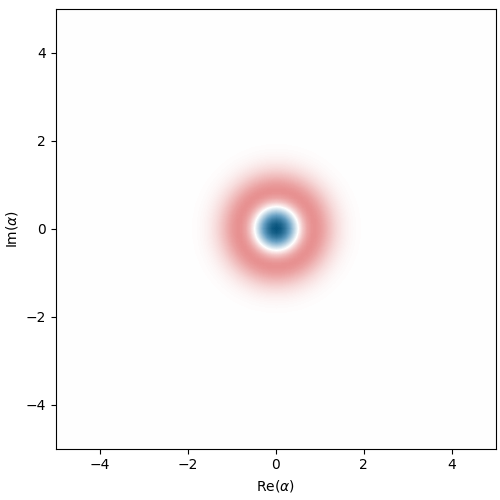

In [14]:
na = 15 # Hilbert space dimension
nb = 5
a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilaiton operator
b = dq.tensor(dq.eye(na), dq.destroy(nb))

kappa_b = 10 # MHz
eps_d = 4
g_2 = 1 # MHz  
kappa_a = 0 # MHz

eps_2 = 2 * g_2 * eps_d / kappa_b
kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

print(f"Estimated cat size: {alpha_estimate:.2f}")

H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

loss_b = jnp.sqrt(kappa_b) * b
loss_a = jnp.sqrt(kappa_a) * a

tsave = jnp.linspace(0, 3, 100)

psi0 = dq.tensor(dq.fock(na, 1), dq.fock(nb,0)) # initial state

res = dq.mesolve(H, [loss_b, loss_a], psi0, tsave)
dq.plot.wigner_gif(dq.ptrace(res.states, 0))

## Decay of logical information under single photon loss

Up to this point, the single-photon loss rate has been set to zero. We now consider a more realistic scenario by including single-photon loss while maintaining cat qubit stabilization.

We initialize the system in the logical state
$\ket{-z_L} = \ket{1}_{\alpha} = \ket{-\alpha},$
and evolve under the combined effects of engineered two-photon stabilization and single-photon loss.

The resulting dynamics illustrate the emergence of bit-flip errors: over time, the state gradually transitions from $\ket{-z_L} = \ket{-\alpha}$ (left blob) toward $\ket{+z_L} = \ket{\alpha}$ (right blob). In the visualization, this process appears as a shift of color from the left blob to the right blob, reflecting the change in logical state.

Estimated cat size: 1.66


|██████████| 100.0% ◆ elapsed 2.15s ◆ remaining 0.00ms  
100%|██████████| 50/50 [00:02<00:00, 17.67it/s]


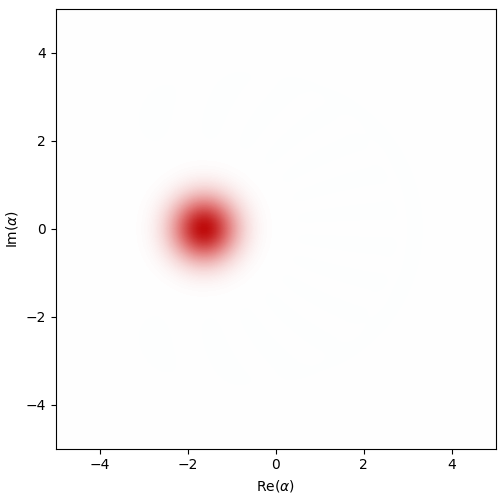

In [15]:
na = 15 # Hilbert space dimension
nb = 5
a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilaiton operator
b = dq.tensor(dq.eye(na), dq.destroy(nb))

kappa_b = 10 # MHz
eps_d = 4
g_2 = 1 # MHz  
kappa_a = 1 # MHz

eps_2 = 2 * g_2 * eps_d / kappa_b
kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

print(f"Estimated cat size: {alpha_estimate:.2f}")

H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

loss_b = jnp.sqrt(kappa_b) * b
loss_a = jnp.sqrt(kappa_a) * a

tsave = jnp.linspace(0, 100, 100)

psi0 = dq.tensor(dq.coherent(na, -alpha_estimate), dq.fock(nb,0)) # initial state

res = dq.mesolve(H, [loss_b, loss_a], psi0, tsave)
dq.plot.wigner_gif(dq.ptrace(res.states, 0))

In fact, we can even fit the logical bit flip and phase flip lifetimes of the cat qubit under single photon loss by initializing in $\ket{-x}$ or $\ket{-z}$ and measuring the decay of logical information under single photon loss. 

In [16]:
def measure_lifetime(initial_state, tfinal):
    na = 15 # Hilbert space dimension
    nb = 5
    a = dq.tensor(dq.destroy(na), dq.eye(nb)) # annihilaiton operator
    b = dq.tensor(dq.eye(na), dq.destroy(nb))

    kappa_b = 10 # MHz
    eps_d = 4
    g_2 = 1 # MHz  
    kappa_a = 1 # MHz

    eps_2 = 2 * g_2 * eps_d / kappa_b
    kappa_2 = 4 * jnp.abs(g_2)**2/kappa_b
    alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2 - kappa_a/4))

    print(f"Estimated cat size: {alpha_estimate:.2f}")

    H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b

    loss_b = jnp.sqrt(kappa_b) * b
    loss_a = jnp.sqrt(kappa_a) * a

    tsave = jnp.linspace(0, tfinal, 100)

    g_state = dq.coherent(na, alpha_estimate)
    e_state = dq.coherent(na, -alpha_estimate)

    basis = {
        "+z": g_state,
        "-z": e_state,
        "+x": (g_state + e_state) / jnp.sqrt(2),
        "-x": (g_state - e_state) / jnp.sqrt(2),
        "+y": (g_state + 1j*e_state) / jnp.sqrt(2),
        "-y": (g_state - 1j*e_state) / jnp.sqrt(2),
    }

    sx = (1j * jnp.pi * a.dag() @ a).expm()
    
    # This construction of sigmaz will not work without a good estimate of alpha, which is hard to come by in experiment.
    sz = basis["+z"] @ basis["+z"].dag() - basis["-z"] @ basis["-z"].dag()
    sz = dq.tensor(sz, dq.eye(nb))

    psi0 = dq.tensor(basis[initial_state], dq.fock(nb,0)) # initial state

    res = dq.mesolve(
        H, 
        [loss_b, loss_a], 
        psi0, 
        tsave, 
        options=dq.Options(progress_meter=False),
        exp_ops=[sx, sz]
    )

    return res

In [17]:
# model: y = A * exp(-t/tau) + C
def model(p, t):
    A, tau, C = p
    return A * jnp.exp(-t/tau) + C

def residuals(p, x, y):
    return model(p, x) - y


def robust_exp_fit(x, y):
    # smart initialization
    A0 = y.max() - y.min()
    C0 = y.min()
    tau0 = (x.max() - x.min())
    p0 = [A0, tau0, C0]

    # robust fit (soft_l1 or huber are key)
    res = least_squares(
        residuals,
        p0,
        args=(x, y),
        bounds=([0, 0, -jnp.inf], [jnp.inf, jnp.inf, jnp.inf]),
        loss="soft_l1",   # try "huber" too
        f_scale=0.1       # tune based on noise level
    )

    A, tau, C = res.x
    y_fit = model(res.x, x)

    return {
        "popt": res.x,
        "y_fit": y_fit,
    }

Estimated cat size: 1.66


/opt/miniconda3/envs/ab-env/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


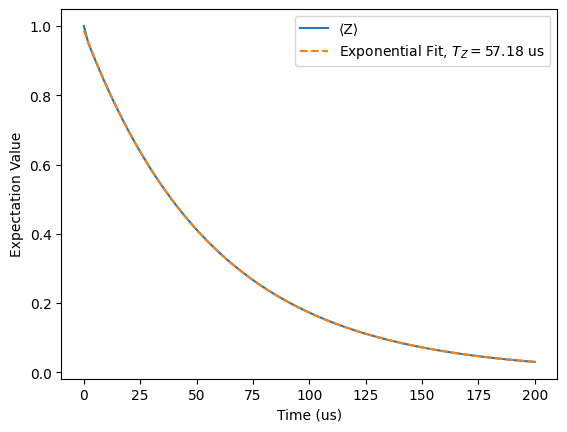

In [18]:
res = measure_lifetime("+z", 200)
szt = res.expects[1,:].real
ts = res.tsave

y = szt 
x = ts 
fit = robust_exp_fit(x, y)
y_fit = fit["y_fit"]
Tz = fit["popt"][1]

plt.plot(ts, szt, label="⟨Z⟩")
plt.plot(ts, y_fit, label="Exponential Fit, $T_Z = $" + "{:.2f}".format(Tz) + " us", linestyle="--")
plt.xlabel("Time (us)")
plt.ylabel("Expectation Value")
plt.legend()
plt.show()

Estimated cat size: 1.66


/opt/miniconda3/envs/ab-env/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:34: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


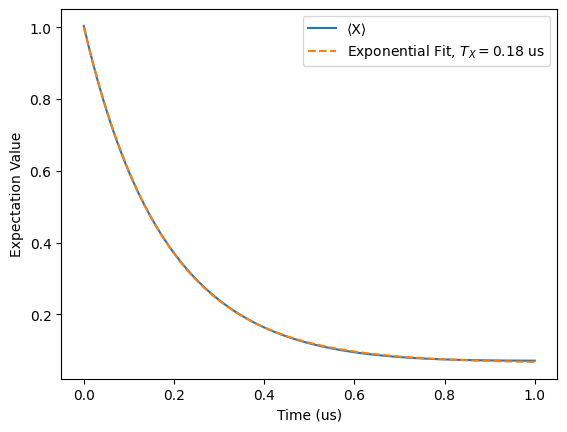

In [19]:
res = measure_lifetime("+x",1.0)
sxt = res.expects[0,:].real
ts = res.tsave

y = sxt 
x = ts 
fit = robust_exp_fit(x, y)
y_fit = fit["y_fit"]
popt = fit["popt"]
Tx = fit["popt"][1]

plt.plot(ts, sxt, label="⟨X⟩")
plt.plot(ts, y_fit, label="Exponential Fit, $T_X = $" + "{:.2f}".format(Tx) + " us", linestyle="--")
plt.xlabel("Time (us)")
plt.ylabel("Expectation Value")
plt.legend()
plt.show()

In [20]:
print("Bias: ", Tz/Tx)

Bias:  320.2825835967476


# Challenge Description

In the **Simple Pi Pulse** section of this notebook, we walked through an end-to-end example of online optimization for pi pulse calibration, including robustness to hardware drift.

In the **Cat Qubit Stabilization** section, we introduced a Hamiltonian system for stabilizing a cat qubit. Several tunable parameters control the cat size and, in turn, the $T_X$ and $T_Z$ lifetimes of the stabilized state.

---

**Core Challenge**

Your goal is to **design and benchmark an online optimization algorithm** for cat qubit stabilization that maintains performance under hardware drift.

Because cat qubits are biased qubits, your optimizer must pursue two objectives simultaneously:
- Achieve a target bias $\eta = T_Z / T_X$
- Maximize the absolute values of $T_X$ and $T_Z$

To start, the knobs you will tune are:
- The complex valued $g_2$ and $\epsilon_d$ numbers, for a total of four real knobs. 

You are welcome to adjust the loss rates $\kappa_b$ and $\kappa_a$ but not with the online optimizer, as these *usually* cannot be tuned in-situ (i.e. after a device has been made). 

---

**Dimensions to Explore**

*1. Reward Function Design*

Define a reward that captures both lifetime maximization and bias targeting. A good reward should be:
- **Experimentally efficient** — extracting $T_{X/Z}$ via exponential decay fits requires multiple measurement points per curve, so consider whether a proxy or surrogate is more practical. This may also speed up your simulation. 
- **Robust to uncertainty** — measuring the logical expectation $\langle X_L \rangle$ is especially difficult without a reliable estimate of the size of the stabilized cat qubits.


*2. Choice of Online Optimizer*

Refs [1–2] use PPO (a reinforcement learning algorithm); the pi pulse example uses CMA-ES. Many other options exist, both RL-based and otherwise. You are free to use any optimizer you find well-motivated, and we encourage benchmarking multiple approaches against each other.


*3. Drift and Noise Modeling*

Formulate phenomenological models for environmental drift and evaluate how well your optimizer adapts. Relevant drift mechanisms include:
- Amplitude shifts in the buffer drive (i.e. introduce a complex amplitude prefactor in the $g_2$ term that drifts with epoch)
- Frequency shift of the storage resonator (i.e. shifting detuning of the two-photon drive $g_2$)
- Kerr nonlinearity appearing in storage
- Coupling to a TLS resonant with the storage mode
- Degradation in measurement SNR

To counteract drift, you may introduce additional control knobs as needed. For example, if the storage resonator develops a frequency offset $\Delta a^\dagger a$, a natural compensation is to add a tunable drive detuning $\Delta_d a^\dagger a$ - giving the online optimizer a knob to correct for it directly.

Giving structure to your drift model lets you systematically characterize optimizer responsiveness, as done in [2].

*4. Extension to Other Cat Flavors*

Many variants of cat qubits exist, each with a modified stabilization Hamiltonian. For example, the *moon cat* [3] introduces an additional term Hamiltonian term $g_2 \lambda a^\dagger a b$ and control knob $\lambda$ that deforms the circular blobs of a cat into moon-shaped states. You are welcome to explore this zoo of cats.

*5. Extension to Single-Qubit Gates*

The core challenge focuses on preserving bias and lifetimes while the cat qubit idles. A natural extension is to maintain those same targets while actively performing single-qubit gates on the cat qubit.

---

**Advice**

To begin, you do not need to explore every dimension above. We recommend **building a complete end-to-end solution first**, then iterating on specific directions. For instance, your reward function does not need to be maximally measurement-efficient from the start — it just needs to reliably reflect lifetime and bias. You are then free to dive deep into one of these dimensions or explore many. 


---
1. Real-time quantum error correction beyond break-even, Volodymyr Sivak et al. (2023). [https://arxiv.org/abs/2211.09116](https://arxiv.org/abs/2211.09116)
2. Reinforcement Learning Control of Quantum Error Correction, Volodymyr Sivak et al. (2025). [https://arxiv.org/abs/2511.08493](https://arxiv.org/abs/2511.08493)
3. Enhancing dissipative cat qubit protection by squeezing, R. Rousseau et al. (2025). [https://arxiv.org/pdf/2502.07892](https://arxiv.org/pdf/2502.07892)

**NEW LINEAR EXPONENTIAL FIT FUNCTION**

In [15]:
def _linear_exp_fit(ts, ys):
    """
    Fit y = A * exp(-t/tau) by linearizing: log(y) = log(A) - t/tau.
    Returns tau. Pure JAX — compatible with jit and vmap.
    
    Clips ys to avoid log(0) in case of numerical noise.
    """
    log_ys = jnp.log(jnp.clip(ys, 1e-10, None))
    # jnp.polyfit(x, y, deg=1) returns [slope, intercept]
    coeffs = jnp.polyfit(ts, log_ys, 1)   # slope = -1/tau
    slope  = coeffs[0]
    tau    = -1.0 / slope
    return tau

In [18]:
# ============================================================
# CAT QUBIT OPTIMIZER — jit + vmap version
# ============================================================

na_opt = 15
nb_opt = 5
kappa_b_opt = 10.0
kappa_a_opt = 1.0

a_opt = dq.tensor(dq.destroy(na_opt), dq.eye(nb_opt))
b_opt = dq.tensor(dq.eye(na_opt), dq.destroy(nb_opt))

T_FINAL_Z = 80.0
T_FINAL_X = 2.0
N_TIMES    = 60

LAMBDA_BIAS = 2.0


@jit
def cat_loss_func(x):
    """
    x = [Re(g2), Im(g2), Re(eps_d), Im(eps_d)]
    Fully pure JAX — no scipy, no Python callbacks.
    Uses linearised exponential fit (jnp.polyfit) for Tz and Tx.
    """
    g2    = x[0] + 1j * x[1]
    eps_d = x[2] + 1j * x[3]

    eps_2     = 2 * g2 * eps_d / kappa_b_opt
    kappa_2   = 4 * jnp.abs(g2)**2 / kappa_b_opt
    alpha_est = jnp.sqrt(jnp.abs(2 / kappa_2 * (eps_2 - kappa_a_opt / 4)))

    H      = (jnp.conj(g2) * a_opt @ a_opt @ b_opt.dag()
              + g2 * a_opt.dag() @ a_opt.dag() @ b_opt
              - eps_d * b_opt.dag()
              - jnp.conj(eps_d) * b_opt)
    loss_b = jnp.sqrt(kappa_b_opt) * b_opt
    loss_a = jnp.sqrt(kappa_a_opt) * a_opt

    g_state = dq.coherent(na_opt, alpha_est)
    e_state = dq.coherent(na_opt, -alpha_est)

    # build observables from storage operator only, then tensor
    a_storage  = dq.destroy(na_opt)
    sx_storage = (1j * jnp.pi * a_storage.dag() @ a_storage).expm()
    sx = dq.tensor(sx_storage, dq.eye(nb_opt))
    sz = dq.tensor(
        g_state @ g_state.dag() - e_state @ e_state.dag(),
        dq.eye(nb_opt)
    )

    # Tz: evolve from |+z⟩, fit log(⟨σ_z⟩) vs t
    ts_z  = jnp.linspace(0, T_FINAL_Z, N_TIMES)
    res_z = dq.mesolve(H, [loss_b, loss_a],
                       dq.tensor(g_state, dq.fock(nb_opt, 0)),
                       ts_z, exp_ops=[sz],
                       options=dq.Options(progress_meter=False))
    szt = res_z.expects[0, :].real
    Tz  = -1.0 / jnp.polyfit(ts_z, jnp.log(jnp.clip(szt, 1e-10, None)), 1)[0]
    Tz  = jnp.maximum(Tz, 1e-6)

    # Tx: evolve from |+x⟩, fit log(⟨σ_x⟩) vs t
    ts_x  = jnp.linspace(0, T_FINAL_X, N_TIMES)
    res_x = dq.mesolve(H, [loss_b, loss_a],
                       dq.tensor((g_state + e_state) / jnp.sqrt(2), dq.fock(nb_opt, 0)),
                       ts_x, exp_ops=[sx],
                       options=dq.Options(progress_meter=False))
    sxt = res_x.expects[0, :].real
    Tx  = -1.0 / jnp.polyfit(ts_x, jnp.log(jnp.clip(sxt, 1e-10, None)), 1)[0]
    Tx  = jnp.maximum(Tx, 1e-6)

    reward = (jnp.log(Tz) + jnp.log(Tx)
              - LAMBDA_BIAS * jnp.log(Tz / Tx)**2)
    return -reward


batched_cat_loss = jit(vmap(cat_loss_func))


# ============================================================
# CMA-ES loop
# ============================================================
BATCH_SIZE = 12
N_EPOCHS   = 5

optimizer_cat = SepCMA(
    mean=jnp.array([1.0, 0.0, 4.0, 0.0]),
    sigma=0.5,
    bounds=jnp.array([
        [0.1,  5.0],
        [-3.0, 3.0],
        [0.5, 10.0],
        [-3.0, 3.0],
    ]),
    population_size=BATCH_SIZE,
    seed=0,
)

mean_history_cat   = []
reward_history_cat = []
reward_std_cat     = []
Tz_history_cat     = []
Tx_history_cat     = []

print(f"{'Epoch':>5} | {'Re(g2)':>7} {'Im(g2)':>7} {'Re(ε_d)':>8} {'Im(ε_d)':>8} "
      f"| {'avg loss':>9}")
print("-" * 70)

for epoch in range(N_EPOCHS):
    xs     = jnp.array([optimizer_cat.ask()
                        for _ in range(optimizer_cat.population_size)])
    losses = batched_cat_loss(xs)   # all 12 candidates in one parallel call

    optimizer_cat.tell(list(zip(xs, losses)))

    mean_history_cat.append(optimizer_cat.mean.copy())
    reward_history_cat.append(float(jnp.mean(losses)))
    reward_std_cat.append(float(jnp.std(losses)))

    # extract Tz/Tx from best candidate for logging
    # re-use losses already computed — no extra simulation needed
    best_x = xs[int(jnp.argmin(losses))]
    best_loss = float(jnp.min(losses))

    # compute Tz and Tx separately for the history plots
    # (run once per epoch on best candidate only, not the full batch)
    best_losses_tz_tx = batched_cat_loss(best_x[None, :])  # shape (1,)

    # to get actual Tz/Tx values for plotting we run the single-candidate
    # version and extract them inline
    g2_best    = best_x[0] + 1j * best_x[1]
    eps_d_best = best_x[2] + 1j * best_x[3]

    eps_2_b     = 2 * g2_best * eps_d_best / kappa_b_opt
    kappa_2_b   = 4 * jnp.abs(g2_best)**2 / kappa_b_opt
    alpha_est_b = jnp.sqrt(jnp.abs(2 / kappa_2_b * (eps_2_b - kappa_a_opt / 4)))

    H_b      = (jnp.conj(g2_best) * a_opt @ a_opt @ b_opt.dag()
                + g2_best * a_opt.dag() @ a_opt.dag() @ b_opt
                - eps_d_best * b_opt.dag()
                - jnp.conj(eps_d_best) * b_opt)
    loss_b_b = jnp.sqrt(kappa_b_opt) * b_opt
    loss_a_b = jnp.sqrt(kappa_a_opt) * a_opt

    g_b = dq.coherent(na_opt, alpha_est_b)
    e_b = dq.coherent(na_opt, -alpha_est_b)

    a_s  = dq.destroy(na_opt)
    sx_b = dq.tensor((1j * jnp.pi * a_s.dag() @ a_s).expm(), dq.eye(nb_opt))
    sz_b = dq.tensor(g_b @ g_b.dag() - e_b @ e_b.dag(), dq.eye(nb_opt))

    ts_z_b  = jnp.linspace(0, T_FINAL_Z, N_TIMES)
    res_z_b = dq.mesolve(H_b, [loss_b_b, loss_a_b],
                         dq.tensor(g_b, dq.fock(nb_opt, 0)),
                         ts_z_b, exp_ops=[sz_b],
                         options=dq.Options(progress_meter=False))
    szt_b = res_z_b.expects[0, :].real
    Tz_b  = float(-1.0 / jnp.polyfit(ts_z_b,
                                      jnp.log(jnp.clip(szt_b, 1e-10, None)), 1)[0])

    ts_x_b  = jnp.linspace(0, T_FINAL_X, N_TIMES)
    res_x_b = dq.mesolve(H_b, [loss_b_b, loss_a_b],
                         dq.tensor((g_b + e_b) / jnp.sqrt(2), dq.fock(nb_opt, 0)),
                         ts_x_b, exp_ops=[sx_b],
                         options=dq.Options(progress_meter=False))
    sxt_b = res_x_b.expects[0, :].real
    Tx_b  = float(-1.0 / jnp.polyfit(ts_x_b,
                                      jnp.log(jnp.clip(sxt_b, 1e-10, None)), 1)[0])

    Tz_history_cat.append(max(Tz_b, 1e-6))
    Tx_history_cat.append(max(Tx_b, 1e-6))

    if True: #epoch % 5 == 0:
        m = optimizer_cat.mean
        print(f"{epoch:5d} | {m[0]:7.3f} {m[1]:7.3f} {m[2]:8.3f} {m[3]:8.3f} "
              f"| {Tz_b:9.3f} {Tx_b:9.3f} {Tz_b/max(Tx_b,1e-9):8.2f} "
              f"| {float(jnp.mean(losses)):9.4f}")

m = optimizer_cat.mean
print(f"\nDone. Best mean: Re(g2)={m[0]:.4f}, Im(g2)={m[1]:.4f}, "
      f"Re(ε_d)={m[2]:.4f}, Im(ε_d)={m[3]:.4f}")
print(f"Final Tz={Tz_history_cat[-1]:.3f} μs,  Tx={Tx_history_cat[-1]:.3f} μs,  "
      f"Tz/Tx={Tz_history_cat[-1]/max(Tx_history_cat[-1],1e-9):.2f}")

Epoch |  Re(g2)  Im(g2)  Re(ε_d)  Im(ε_d) |  avg loss
----------------------------------------------------------------------
    0 |   0.987  -0.423    3.494    0.447 |    25.929     2.029    12.78 |   59.3900
    5 |   2.847  -2.143    1.625    0.640 |     5.250     6.551     0.80 |    2.6819


KeyboardInterrupt: 

In [ ]:
# ============================================================
# PLOTS  —  run after the cell above finishes
# ============================================================
epochs_cat = list(range(N_EPOCHS))
fig, axes  = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.plot(epochs_cat, reward_history_cat)
ax.fill_between(epochs_cat,
                jnp.array(reward_history_cat) - jnp.array(reward_std_cat),
                jnp.array(reward_history_cat) + jnp.array(reward_std_cat),
                alpha=0.2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Loss vs Epoch")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_cat, Tz_history_cat, label="$T_Z$ (μs)")
ax.plot(epochs_cat, Tx_history_cat, label="$T_X$ (μs)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Lifetime (μs)"); ax.set_title("Lifetimes vs Epoch")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
bias_cat = [Tz/max(Tx,1e-9) for Tz,Tx in zip(Tz_history_cat, Tx_history_cat)]
ax.plot(epochs_cat, bias_cat, color="purple")
ax.axhline(1.0, linestyle="--", color="gray", label="Target = 1")
ax.set_xlabel("Epoch"); ax.set_ylabel("$T_Z / T_X$"); ax.set_title("Bias vs Epoch")
ax.set_yscale("log"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()